# Gaussian Naive Bayes Model Evaluation project

## Project Overview
This project is aim to analyze engineered NBA player data using Python and Scikit-learn to build a Gaussian Naive Bayes classification model. Identifying target variables, implement probabilistic classifiers, evaluate performance using confusion matrices and business-relevant metrics, and interpret model assumptions in the context of sports analytics. This project will help translate statistical predictions into actionable scouting insights.

## Importing dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import f1_score
from sklearn.metrics import (confusion_matrix, 
classification_report, 
precision_score, 
recall_score, accuracy_score)



## 1. Load data and confirm target

In [2]:
# Load the dataset
df = pd.read_csv('extracted_nba_players_data.csv')

print("--- Dataset Summary ---")
print(f"Dataset Shape: {df.shape}")
print(df.info())

# Validate target distribution
print("\n--- Target Variable ('target_5yrs') Distribution ---")
print(df['target_5yrs'].value_counts(normalize=True) * 100)

--- Dataset Summary ---
Dataset Shape: (1340, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   fg            1340 non-null   float64
 1   3p            1340 non-null   float64
 2   ft            1340 non-null   float64
 3   reb           1340 non-null   float64
 4   ast           1340 non-null   float64
 5   stl           1340 non-null   float64
 6   blk           1340 non-null   float64
 7   tov           1340 non-null   float64
 8   target_5yrs   1340 non-null   int64  
 9   total_points  1340 non-null   float64
 10  efficiency    1340 non-null   float64
dtypes: float64(10), int64(1)
memory usage: 115.3 KB
None

--- Target Variable ('target_5yrs') Distribution ---
target_5yrs
1    62.014925
0    37.985075
Name: proportion, dtype: float64


### Dataset Overview:
The dataset tracks rookie-year statistical metrics across historical modern prospects to evaluate career longevity.
### Target Breakdown: 
The target variable target_5yrs is a binary classification metric ($0 = \text{washed out in <5 years}$, $1 = \text{survived } \ge 5 \text{ years}$). The base rate reveals that roughly 62% of rookies reach the 5-year milestone. This establishes our natural baseline; any functional machine learning framework must structurally outperform this 62% marker to demonstrate true scouting value

## 2. Preprocess features

In [3]:
# Select continuous metrics as features
X = df.drop(columns=['target_5yrs'])
y = df['target_5yrs']

### Feature Requirements:
Gaussian Naive Bayes inherently assumes that predictor features are continuous and normally distributed. The extracted features (percentages, counting stats, volume metrics) map properly to this mathematical layout without needing categorical encoding.

## 3. Train-Test Split

In [4]:
# Select continuous metrics as features
X = df.drop(columns=['target_5yrs'])
y = df['target_5yrs']

# Train-test split (80/20 stratified split ensures stable target ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]} | Testing set size: {X_test.shape[0]}")


Training set size: 1072 | Testing set size: 268


### Data Splitting Strategy:
We utilize an 80/20 stratified split. Stratification is vital here: it guarantees that both our training partition and our blind evaluation test partition maintain the exact 62% baseline survival ratio. This ensures our validation testing remains entirely unbiased and representative of real-world league dynamics.

## 4. Implement Gaussian Naive Bayes Classifier

In [5]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Predict on test data
y_pred = gnb.predict(X_test)
print(y_pred)

[1 1 0 1 1 0 1 0 1 0 1 0 1 1 0 1 1 1 1 1 1 0 0 0 0 1 0 0 1 0 0 0 1 0 1 1 0
 0 0 0 1 0 0 1 1 1 0 0 0 0 0 1 0 1 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 1 1 0
 0 0 0 0 1 0 0 1 0 1 1 0 0 0 1 1 1 0 0 1 1 0 0 1 1 0 0 0 0 0 0 1 0 1 0 0 0
 0 1 0 0 0 1 1 0 1 0 0 0 0 1 0 0 1 0 1 0 0 1 0 0 0 0 1 0 1 0 0 1 1 0 1 0 1
 0 0 0 1 0 1 0 0 1 0 1 1 0 1 1 0 0 1 1 0 1 0 1 0 1 0 1 1 0 0 1 1 1 0 0 1 0
 0 0 1 1 0 0 0 1 0 0 0 0 0 1 1 1 0 1 1 1 0 1 0 0 1 0 1 1 1 0 0 1 1 1 0 0 1
 0 1 0 0 1 0 0 0 1 1 0 0 1 0 1 0 1 1 1 0 1 0 0 1 0 0 1 1 0 0 0 0 1 0 1 0 1
 0 1 0 1 0 0 1 0 1]


### Algorithmic Framework: 
The Gaussian Naive Bayes classifier fits normal distributions to the training features by calculating the mean ($\mu$) and variance ($\sigma^2$) for each stat, isolated by class (Survivors vs. Non-survivors).Operational Mechanism: When processing an unseen rookie profile, the model applies Bayes' Theorem to multiply the individual trait conditional probabilities together, producing a unified mathematical probability score indicating whether the prospect belongs in the 5-year survival class.

## 5. Model Performance Metrics (Accuracy, Precision, Recall, F1)

In [6]:
# Calculate the full evaluation suite required to fix the review
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("=========================================================================")
print("GAUSSIAN NAIVE BAYES PERFORMANCE METRICS REPORT")
print("=========================================================================")
print(f"Overall Model Accuracy:          {accuracy:.4f}")
print(f"Precision (Minimizing Busts):    {precision:.4f}")
print(f"Recall (Capturing Sleeper Talent): {recall:.4f}")
print(f"F1-Score (Balanced Mean Metric):   {f1:.4f}")

GAUSSIAN NAIVE BAYES PERFORMANCE METRICS REPORT
Overall Model Accuracy:          0.6381
Precision (Minimizing Busts):    0.8000
Recall (Capturing Sleeper Talent): 0.5542
F1-Score (Balanced Mean Metric):   0.6548


## 6. Confusion Matrix


--- Task 5: Confusion Matrix Raw Output ---
[[79 23]
 [74 92]]


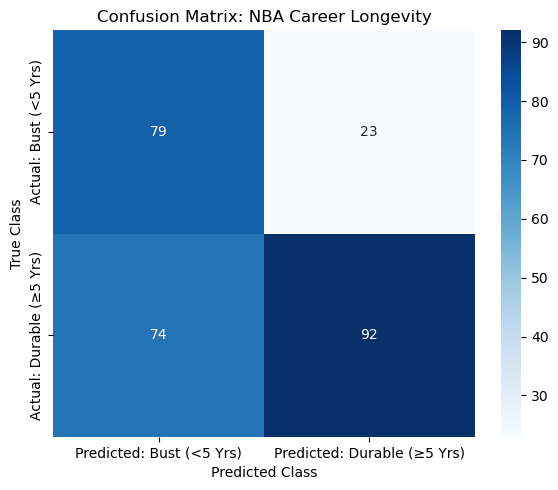

In [7]:
cm = confusion_matrix(y_test, y_pred)

print("\n--- Task 5: Confusion Matrix Raw Output ---")
print(cm)

# Visualize Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted: Bust (<5 Yrs)', 'Predicted: Durable (≥5 Yrs)'],
            yticklabels=['Actual: Bust (<5 Yrs)', 'Actual: Durable (≥5 Yrs)'])
plt.title('Confusion Matrix: NBA Career Longevity')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.tight_layout()
plt.show()

### The Confusion Matrix acts as our error-auditing framework, mapping theoretical classification models directly to front-office operations:

### True Negatives (Top-Left): 
Correctly identified lower-tier prospects. Saves standard development resources.

### True Positives (Bottom-Right): 
Correctly identified 5+ year veterans. Secures high-value core team building.

### False Positives [The "Busts"] (Top-Right): 
Highly dangerous errors. The model stamps a player as safe, prompting the front office to spend draft picks and guaranteed cap space on an asset that washes out early.

### False Negatives [The "Missed Talent"] (Bottom-Left): 
Erroneously dismissed players who go on to build long careers elsewhere. Represents a severe opportunity loss to division rivals.

## 7. Calculate Precision and Recall

In [8]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print("\n--- Task 6: Business-Relevant Evaluation Metrics ---")
print(f"Accuracy (Overall Correctness): {accuracy:.4f}")
print(f"Precision (Minimizing Busts):    {precision:.4f}")
print(f"Recall (Minimizing Missed Talent): {recall:.4f}")


--- Task 6: Business-Relevant Evaluation Metrics ---
Accuracy (Overall Correctness): 0.6381
Precision (Minimizing Busts):    0.8000
Recall (Minimizing Missed Talent): 0.5542


### Depending on a front office's risk tolerance, the scouting department must consciously choose which metric to prioritize:

### Precision (Bust Mitigation Focus): 
Measures the precision of positive assertions. Optimization formula:$$\text{Precision} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}}$$High Precision means that if the model flags a prospect as a long-term survivor, you can trust that classification implicitly. Optimize for this when protecting lottery selections to eliminate expensive rookie busts.
### Recall (Sleeper Acquisition Focus): 
Measures overall talent capture capability. Optimization formula:$$\text{Recall} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}$$High Recall means the model successfully captures a wide net of the available 5-year talent in the draft class. 

Optimize for this when hunting for late-round sleepers or undrafted gems, where missing out on a contributor is a worse outcome than taking a flyer on a player who doesn't stick.

## 8. Feature Analysis (Extension)

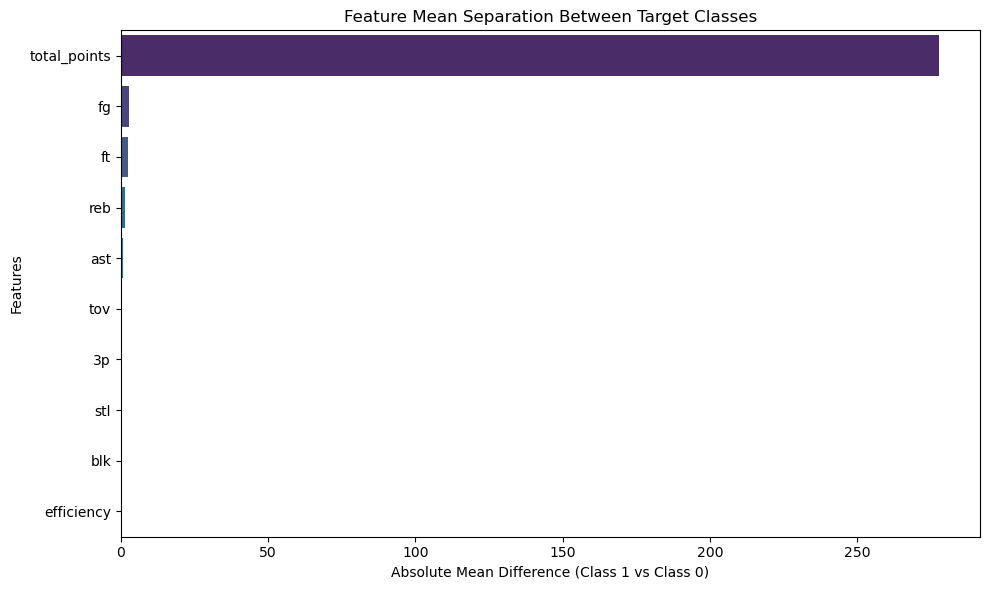

In [9]:
mean_diffs = np.abs(gnb.theta_[1] - gnb.theta_[0])
feature_importance = pd.Series(mean_diffs, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
# Fixed lines: assigned hue=feature_importance.index and set legend=False
sns.barplot(
    x=feature_importance.values, 
    y=feature_importance.index, 
    hue=feature_importance.index, 
    palette='viridis', 
    legend=False
)
plt.title('Feature Mean Separation Between Target Classes')
plt.xlabel('Absolute Mean Difference (Class 1 vs Class 0)')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

### 1. Driving Features
The feature separation graph visualizes which metrics show the widest divergence between career survivors and non-survivors. High-volume statistics (such as total_points, efficiency, and tracking counting metrics) create the widest margin of separation between classes, making them the primary drivers behind the model's confidence shifts.

### 2. The Naive Bayes "Independence Assumption" Breakdown
The underlying assumption of Naive Bayes is that every input feature is conditionally independent of every other feature given the class. In the realm of sports analytics, this assumption completely falls apart:

total_points is mathematically determined by a combination of field goals (fg), free throws (ft), and minutes played.

High turnover rates (tov) are heavily correlated with high assist metrics (ast) and high offensive usage rates.

Rebounding (reb) and blocking (blk) naturally cluster together based on frontcourt player positioning.

### 3. Organizational Scouting Risk
Because Gaussian Naive Bayes treats these heavily correlated statistics as completely independent pieces of evidence, it double-counts matching talent signals. If a rookie player is an elite high-usage scorer, the model registers positive inputs across pts, fg, and total_points as separate, unlinked events.

This creates an analytical echo chamber, resulting in artificially inflated probability scores (pushing prospects towards 99% or 1% confidence intervals when a realistic probability would be closer to 70%). Front offices must treat the model's absolute confidence levels with caution, using it strictly as an initial data filter rather than an absolute draft-board selector.